# Lab 4: Product listings - ChatGPT API

## Step 1: Set-Up

In [1]:
# Set-Up
"""
Automation of creation of product listings with ChatGPT
Author: Carlos Martinez Boto
"""
import os
from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel
from typing import List
load_dotenv()
import json

# Initialize client
client = OpenAI(api_key = os.getenv("OPENAI_API_KEY"))

## Step 2: Preparing the Dataset

In [2]:
# pip install datasets
from datasets import load_dataset
import requests
from PIL import Image
import pandas as pd
from pathlib import Path

In [3]:
# Load dataset from HuggingFace
print("Loading product dataset...")
try:
    # Try loading the dataset
    dataset = load_dataset("ashraq/fashion-product-images-small", split="train[:100]")  # First 100 samples
    print(f"✓ Loaded {len(dataset)} products")
    
    # Convert to pandas for easier manipulation
    products_df = pd.DataFrame(dataset)
    print(f"Dataset columns: {products_df.columns.tolist()}")
    
except Exception as e:
    print(f"⚠ Could not load HuggingFace dataset: {e}")
    print("Using local images instead...")
    
    # Alternative: Use local images
    # Create a products.json file with product information
    products_data = [
        {
            "id": 1,
            "name": "Wireless Headphones",
            "price": 79.99,
            "category": "Electronics",
            "image_path": "images/product1.jpg"
        },
        # Add more products...
    ]
    
    products_df = pd.DataFrame(products_data)


Loading product dataset...


✓ Loaded 100 products
Dataset columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image']


In [4]:
# Create images directory
images_dir = Path("product_images")
images_dir.mkdir(exist_ok=True)
 
print(f"\n✓ Dataset prepared!")
print(f"  Total products: {len(products_df)}")


✓ Dataset prepared!
  Total products: 100


In [5]:
# print(products_df['image'].head())
# from IPython.display import display
# for _, row in products_df.head().iterrows():
#     display(row["image"])

## Step 3: Encoding Images for API

In [6]:
import base64
from io import BytesIO

# Read an image file and returns a Base64-encoded string
def pil_to_base64(img):
    buffer = BytesIO()
    img.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

In [7]:
products_df["image_base64"] = products_df["image"].apply(pil_to_base64)
print(products_df[["image", "image_base64"]].head())

                                               image  \
0  <PIL.JpegImagePlugin.JpegImageFile image mode=...   
1  <PIL.JpegImagePlugin.JpegImageFile image mode=...   
2  <PIL.Image.Image image mode=L size=60x80 at 0x...   
3  <PIL.JpegImagePlugin.JpegImageFile image mode=...   
4  <PIL.Image.Image image mode=RGB size=60x80 at ...   

                                        image_base64  
0  iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAIAAADKqIEEAA...  
1  iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAIAAADKqIEEAA...  
2  iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAAAAABgoUmPAA...  
3  iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAIAAADKqIEEAA...  
4  iVBORw0KGgoAAAANSUhEUgAAADwAAABQCAIAAADKqIEEAA...  


## Step 4: Creating the Product Listing Prompt

In [8]:
def create_product_listing_prompt(df_row):
    """
    Create a prompt for generating product listings.
    
    Parameters:
    - product_name: Name of the product
    - price: Price of the product
    - category: Product category
    - additional_info: Optional additional information
    
    Returns:
    - Formatted prompt string
    """
    prompt = f"""You are an expert e-commerce copywriter. Analyze the product image and create a compelling product listing.
 
Product Information:
- ID: {df_row['id']}
- Gender: {df_row['gender']}
- Category: {df_row['masterCategory']}; {df_row['subCategory']}; {df_row['articleType']}
- Colour: {df_row['baseColour']}
- Season, Usage: {df_row['season']}; {df_row['usage']}
- Year: {df_row['year']:.0f}
- Display name: {df_row['productDisplayName']}
 
Please create a professional product listing that includes:
 
1. **Product Title** (catchy, SEO-friendly, 60 characters max)
2. **Product Description** (detailed, 150-200 words)
   - Highlight key features and benefits
   - Use persuasive language
   - Include relevant details visible in the image
3. **Key Features** (bullet points, 5-7 items)
4. **SEO Keywords** (comma-separated, 10-15 relevant keywords)
 
Format your response as JSON with the following structure:
{{
    "title": "Product title here",
    "description": "Full description here",
    "features": ["Feature 1", "Feature 2", ...],
    "keywords": "keyword1, keyword2, ..."
}}
 
Be specific about what you see in the image. Mention colors, materials, design elements, and any distinctive features."""
    
    return prompt

In [9]:
# Test prompt creation
test_prompt = create_product_listing_prompt(products_df.iloc[0])
 
print("\n" + "="*50)
print("PROMPT TEMPLATE")
print("="*50)
print(test_prompt[:500] + "...")  # Show first 500 characters


PROMPT TEMPLATE
You are an expert e-commerce copywriter. Analyze the product image and create a compelling product listing.

Product Information:
- ID: 15970
- Gender: Men
- Category: Apparel; Topwear; Shirts
- Colour: Navy Blue
- Season, Usage: Fall; Casual
- Year: 2011
- Display name: Turtle Check Men Navy Blue Shirt

Please create a professional product listing that includes:

1. **Product Title** (catchy, SEO-friendly, 60 characters max)
2. **Product Description** (detailed, 150-200 words)
   - Highlight ke...


## Step 5: Calling the ChatGPT API with Vision

In [10]:
response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "user",
        "content": [{"type": "text", "text": test_prompt},
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{products_df['image_base64'].iloc[0]}"}}]
        }
    ]
)
print(response.choices[0].message.content)

```json
{
    "title": "Stylish Turtle Check Men's Navy Blue Shirt",
    "description": "Step into the season with timeless style and comfort with our Turtle Check Men's Navy Blue Shirt. Ideal for casual fall outings, this shirt features a classic check pattern that seamlessly blends navy blue with subtle hues of white and grey, offering a versatile yet sophisticated look. Crafted from breathable cotton fabric, it ensures all-day comfort, whether you're at a brunch or a laid-back evening gathering. The shirt showcases a standard collar and buttoned cuffs, adding a touch of elegance to its casual design. Its relaxed fit provides ease of movement, making it a wardrobe essential for the modern man who values both style and functionality. Effortlessly pair it with jeans or chinos for a polished, ready-for-anything look.",
    "features": [
        "Classic navy blue check pattern",
        "Breathable cotton fabric",
        "Standard collar with button detailing",
        "Comfortable rel

## Step 6: Processing Multiple Products

In [11]:
def generate_response(df_row):
    prompt = create_product_listing_prompt(df_row)
    image = {"url": f"data:image/png;base64,{df_row['image_base64']}"}

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "user",
            "content": [{"type": "text", "text": prompt},
                        {"type": "image_url", "image_url": image}]
            }
        ]
    )
    return response.choices[0].message.content


===== ROW 0 =====


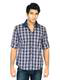

```json
{
    "title": "Stylish Men's Navy Blue Check Shirt for Casual Wear",
    "description": "Elevate your wardrobe this fall with the Turtle Check Men Navy Blue Shirt. This classic piece combines timeless style with modern comfort, making it perfect for any casual outing. Crafted with a premium cotton blend, it offers a soft feel and breathable comfort throughout the day. The navy blue check pattern, complemented by a chic contrasting inner collar, adds a touch of sophistication. Its versatile long sleeves can be rolled up for a laid-back look. Perfect for pairing with jeans or chinos, this shirt ensures you stay effortlessly stylish. Experience a blend of fashion and function with a fit designed for ultimate ease.",
    "features": [
        "Navy blue check pattern",
        "Premium cotton blend material",
        "Contrasting inner collar design",
        "Perfect for fall and casual outings",
        "Full-length sleeves with roll-up option",
        "Comfortable and breathab

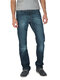

```json
{
    "title": "Peter England Men's Blue Summer Casual Jeans",
    "description": "Step into style and comfort with the Peter England Men's Party Blue Jeans, designed to take your summer wardrobe to the next level. These jeans feature a classic blue wash that’s both versatile and trendy, perfect for casual outings or summer gatherings. The straight-leg cut offers a timeless fit, ensuring both comfort and style throughout the day. Made from high-quality, breathable fabric, these jeans are ideal for warmer weather, keeping you cool while maintaining a chic look. The durable stitching and attention to detail set these jeans apart, making them a must-have staple for any fashion-conscious man. Pair them with anything from a casual tee to a smart shirt and experience the versatility firsthand.",
    "features": [
        "Classic blue wash for versatile styling",
        "Straight-leg fit for timeless appeal",
        "Breathable fabric ideal for summer",
        "Durable stitching e

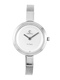

```json
{
    "title": "Elegant Titan Silver Women's Watch - Casual Winter Accessory",
    "description": "Elevate your winter style with the sophisticated Titan Women Silver Watch. This exquisite timepiece features a lustrous silver finish that effortlessly complements any casual ensemble, making it a must-have accessory for the season. Crafted with precision, the sleek round dial is accentuated by minimalist hour markers and delicate hands that offer a timeless appeal. Its durable stainless steel strap ensures a comfortable and secure fit, perfect for daily wear. The watch's simple yet elegant design makes it versatile enough to transition from day to night seamlessly. With Titan's renowned craftsmanship, this watch combines fashion with function, providing an accurate and reliable timekeeping experience. Whether you're heading to a casual brunch or an evening out, the Titan Women Silver Watch is the ideal blend of elegance and simplicity.",
    "features": [
        "Lustrous silver

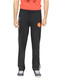

```json
{
    "title": "Manchester United Black Track Pants for Men",
    "description": "Step out in style with the Manchester United Men Solid Black Track Pants, a perfect fusion of comfort and sporty flair. Designed specifically for the modern man, these track pants boast a sleek black color that seamlessly blends with any casual ensemble. Ideal for the fall season, they offer a relaxed fit that's perfect for laid-back weekends or casual outings. Featuring the iconic Manchester United emblem, these pants are not just an apparel choice, but a statement of loyalty to your favorite football club. Made from high-quality materials, they ensure durability and breathability, keeping you comfortable throughout the day. The elasticated waistband provides a snug, adjustable fit while the convenient side pockets offer practical storage for essentials. Whether you're lounging at home or grabbing a coffee with friends, these track pants balance function and fashion effortlessly.",
    "features"

In [12]:
start = 0
end = 4 # len(products_df)
all_results = []

for idx, row in products_df.iloc[start:end].iterrows():
    print(f"\n===== ROW {idx} =====")

    result = generate_response(row)
    products_df.loc[idx, "listing_raw"] = result

    display(row["image"])
    all_results.append(result)
    print(result)

In [15]:
with open("product_listings.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)